# Study 20 — Cricket as a Spatial Game: Field Coverage

## Question

**How does changing a cricket field change which areas are well covered and which areas are left exposed?**

Study 19 represented named fielding positions as points in a common spatial coordinate system. That let us describe **where the fielders are**.

This study takes the next step:

**What do those positions imply about the space available around them?**

We will begin with a deliberately simple geometric model. Imagine a possible ball destination as a point somewhere around the striker. For that point, we can calculate the distance to every fielder and identify the nearest one.

That gives us the basic analytical chain:

    ball destination
    + fielder locations
    → nearest fielder
    → nearest-fielder distance

We will use **nearest-fielder distance as a simple proxy for spatial coverage**:

- a smaller distance means that part of the field is more tightly covered geometrically;
- a larger distance means that part of the field is more exposed.

This is **not** yet a model of whether a fielder would actually stop, catch or reach a particular ball.

Real fielding coverage also depends on factors such as:

- ball speed and trajectory;
- fielder speed, reaction time and direction of movement;
- shot frequency;
- batter handedness and style;
- bowler line and length;
- fielding skill;
- the boundary;
- scoring value and match situation.

We do not yet have those ingredients, so we will not pretend that every possible destination is equally likely or that one field is tactically optimal.

The aim here is narrower:

**Given a set of fielder locations, how is geometric coverage distributed across the field, and how does that distribution change when the field changes?**

We will first compare the illustrative attacking and defensive fields from Study 19, then move individual fielders and measure how those changes redistribute the space around them.

## Reconstructing the two fields

We will begin with the same illustrative attacking and defensive field settings used in Study 19.

The coordinate system is unchanged:

- `(0, 0)` is the centre of the striker's wicket;
- distances are measured in metres;
- `+y` points towards the bowler's end;
- `-y` points behind the striker;
- `+x` is the striker-relative off side;
- `-x` is the striker-relative leg side.

As before, the coordinates assigned to named fielding positions are **representative analytical locations**, not official or universally fixed points.

For this study, that distinction matters even more. Moving a fielder by a few metres will change the calculated coverage around them, so the numerical results should be interpreted as properties of these illustrative field settings rather than exact measurements of every attacking or defensive field used in cricket.

We will reconstruct both fields explicitly in this notebook so that Study 20 remains self-contained.

In [1]:
import pandas as pd

# Recreate the exact illustrative attacking and defensive fields
# used in Study 19.
#
# Coordinates are measured in metres from the striker's wicket:
#   x > 0  -> off side
#   x < 0  -> leg side
#   y > 0  -> towards the bowler's end
#   y < 0  -> behind the striker

attacking_positions = [
    {"position": "Bowler",         "x_m": 0.0,   "y_m": 20.12},
    {"position": "Wicket-keeper",  "x_m": 0.0,   "y_m": -3.0},
    {"position": "First slip",     "x_m": 3.0,   "y_m": -5.0},
    {"position": "Second slip",    "x_m": 5.5,   "y_m": -5.5},
    {"position": "Third slip",     "x_m": 8.0,   "y_m": -6.0},
    {"position": "Gully",          "x_m": 12.0,  "y_m": -8.0},
    {"position": "Point",          "x_m": 22.0,  "y_m": 0.0},
    {"position": "Cover",          "x_m": 28.0,  "y_m": 18.0},
    {"position": "Mid-off",        "x_m": 12.0,  "y_m": 28.0},
    {"position": "Mid-on",         "x_m": -10.0, "y_m": 28.0},
    {"position": "Fine leg",       "x_m": -24.0, "y_m": -25.0},
]

defensive_positions = [
    {"position": "Bowler",           "x_m": 0.0,   "y_m": 20.12},
    {"position": "Wicket-keeper",    "x_m": 0.0,   "y_m": -3.0},
    {"position": "First slip",       "x_m": 3.0,   "y_m": -5.0},
    {"position": "Third man",        "x_m": 38.0,  "y_m": -32.0},
    {"position": "Deep point",       "x_m": 42.0,  "y_m": 0.0},
    {"position": "Deep cover",       "x_m": 40.0,  "y_m": 24.0},
    {"position": "Long-off",         "x_m": 18.0,  "y_m": 42.0},
    {"position": "Long-on",          "x_m": -18.0, "y_m": 42.0},
    {"position": "Deep midwicket",   "x_m": -38.0, "y_m": 26.0},
    {"position": "Deep square leg",  "x_m": -42.0, "y_m": 0.0},
    {"position": "Fine leg",         "x_m": -34.0, "y_m": -36.0},
]

attacking_field = pd.DataFrame(attacking_positions)
defensive_field = pd.DataFrame(defensive_positions)

attacking_field["field"] = "Attacking"
defensive_field["field"] = "Defensive"

fields = pd.concat(
    [attacking_field, defensive_field],
    ignore_index=True,
)

fields

,position,x_m,y_m,field
0,Bowler,0.0,20.12,Attacking
1,Wicket-keeper,0.0,-3.00,Attacking
2,First slip,3.0,-5.00,Attacking
3,Second slip,5.5,-5.50,Attacking
4,Third slip,8.0,-6.00,Attacking
5,Gully,12.0,-8.00,Attacking
6,Point,22.0,0.00,Attacking
7,Cover,28.0,18.00,Attacking
8,Mid-off,12.0,28.00,Attacking
9,Mid-on,-10.0,28.00,Attacking


## Reusing the two fields from Study 19

To study field coverage, we first need fixed fielder locations to measure from.

We will reuse exactly the same two illustrative field settings constructed in Study 19:

- one relatively **attacking** field, with several close catchers behind the striker on the off side;
- one more **defensive** field, with more fielders positioned deeper around the field.

We will also keep exactly the same coordinate convention:

- the centre of the striker's wicket is `(0, 0)`;
- positive `y` points towards the bowler's end;
- negative `y` points behind the striker;
- positive `x` is the striker's off side;
- negative `x` is the striker's leg side;
- distances are measured in metres.

The bowler is represented schematically at the bowler's-end wicket, `(0, 20.12)`, just as in Study 19.

Keeping these assumptions unchanged is important. It means that any differences we find in this study come from the **spatial arrangement of the fielders**, rather than from changing the underlying representation.

The coordinates remain modelling choices rather than official fixed locations for the named cricket positions.

## Define the area we want to measure

A coverage calculation needs more than fielder locations. We also need a set of possible locations around the striker at which to ask:

**How far away is the nearest fielder?**

We will evaluate that question across a regular grid of points.

To keep the comparison finite, we will analyse points within **55 metres of the striker's wicket**.

The 55-metre radius is an analytical choice, not a claim about the size or shape of a cricket ground. Real boundaries vary considerably between grounds and even between different parts of the same ground.

We are simply creating one fixed comparison region that:

- contains all of the fielders in both illustrative settings;
- gives us equal spatial limits for the attacking and defensive fields;
- allows every part of the region to be measured in the same way.

Each grid point will represent a possible ball destination for the geometric analysis.

Importantly, treating equal areas equally does **not** mean that cricket shots are equally likely to travel to every part of the field. Shot probability is not part of this model yet.

In [2]:
import numpy as np

# Create a regular grid covering a 55 m radius around the striker.
# The 55 m radius is an analysis region, not a model of a real boundary.

analysis_radius_m = 55
grid_spacing_m = 1

axis = np.arange(
    -analysis_radius_m,
    analysis_radius_m + grid_spacing_m,
    grid_spacing_m,
)

grid_x, grid_y = np.meshgrid(axis, axis)

coverage_grid = pd.DataFrame(
    {
        "x_m": grid_x.ravel(),
        "y_m": grid_y.ravel(),
    }
)

# Keep only points inside the circular analysis region.
coverage_grid["distance_from_striker_m"] = np.hypot(
    coverage_grid["x_m"],
    coverage_grid["y_m"],
)

coverage_grid = coverage_grid[
    coverage_grid["distance_from_striker_m"] <= analysis_radius_m
].reset_index(drop=True)

print(f"Grid points inside analysis region: {len(coverage_grid):,}")

coverage_grid.head()

Grid points inside analysis region: 9,477


,x_m,y_m,distance_from_striker_m
0,0,-55,55.000000
1,-10,-54,54.918121
2,-9,-54,54.744863
3,-8,-54,54.589376
4,-7,-54,54.451814


## Measure coverage using the nearest fielder

For every point in the analysis grid, we will now calculate the distance to each of the 11 fielders.

For a grid point at `(x, y)` and a fielder at `(x_f, y_f)`, the straight-line distance between them is:

    distance = sqrt((x - x_f)^2 + (y - y_f)^2)

We then keep the smallest of those 11 distances.

That gives each grid point a single value:

    nearest-fielder distance

We will interpret that value as a simple geometric measure of coverage:

- a small nearest-fielder distance means that part of the field has a fielder relatively close by;
- a large nearest-fielder distance means that part of the field is relatively exposed.

The bowler and wicket-keeper are included in the calculation because they are part of the complete XI represented in each field.

This still says nothing about whether a fielder could actually reach a moving ball. It measures only the spatial arrangement of the players.

In [3]:
def add_nearest_fielder(grid, field_df, prefix):
    """
    For every grid point, calculate the distance to every fielder
    and retain the nearest fielder and that distance.
    """

    grid_xy = grid[["x_m", "y_m"]].to_numpy()
    fielder_xy = field_df[["x_m", "y_m"]].to_numpy()

    # Shape:
    #   grid points x fielders x coordinates
    differences = grid_xy[:, None, :] - fielder_xy[None, :, :]

    distances = np.sqrt(
        np.sum(differences ** 2, axis=2)
    )

    nearest_index = np.argmin(distances, axis=1)

    grid[f"{prefix}_nearest_distance_m"] = distances[
        np.arange(len(grid)),
        nearest_index,
    ]

    grid[f"{prefix}_nearest_fielder"] = (
        field_df.iloc[nearest_index]["position"].to_numpy()
    )


# Add coverage measurements for both field settings.
add_nearest_fielder(
    coverage_grid,
    attacking_field,
    "attacking",
)

add_nearest_fielder(
    coverage_grid,
    defensive_field,
    "defensive",
)

coverage_grid[
    [
        "x_m",
        "y_m",
        "attacking_nearest_fielder",
        "attacking_nearest_distance_m",
        "defensive_nearest_fielder",
        "defensive_nearest_distance_m",
    ]
].head(10)

,x_m,y_m,attacking_nearest_fielder,attacking_nearest_distance_m,defensive_nearest_fielder,defensive_nearest_distance_m
0,0,-55,Fine leg,38.418745,Fine leg,38.948684
1,-10,-54,Fine leg,32.202484,Fine leg,30.000000
2,-9,-54,Fine leg,32.649655,Fine leg,30.805844
3,-8,-54,Fine leg,33.120990,Fine leg,31.622777
4,-7,-54,Fine leg,33.615473,Fine leg,32.449961
5,-6,-54,Fine leg,34.132096,Fine leg,33.286634
6,-5,-54,Fine leg,34.669872,Fine leg,34.132096
7,-4,-54,Fine leg,35.227830,Fine leg,34.985711
8,-3,-54,Fine leg,35.805028,Fine leg,35.846897
9,-2,-54,Fine leg,36.400549,Fine leg,36.715120


## Summarise the overall coverage

We now have a nearest-fielder distance for every point in the analysis region under both field settings.

Rather than inspecting thousands of individual grid points, we can summarise the distribution of those distances.

We will compare:

- the **mean** nearest-fielder distance;
- the **median** nearest-fielder distance;
- the **90th percentile**, which describes relatively exposed parts of the field;
- the **maximum** nearest-fielder distance, representing the most geometrically isolated point in our analysis region.

Smaller values indicate that, on average, a grid point has a fielder closer to it.

These statistics should not be interpreted as a single measure of which field is tactically better. An attacking field may deliberately concentrate several players in one important area while leaving much larger spaces elsewhere.

That trade-off is exactly what we want the coverage model to reveal.

In [4]:
summary = pd.DataFrame(
    [
        {
            "field": "Attacking",
            "mean_nearest_distance_m": coverage_grid[
                "attacking_nearest_distance_m"
            ].mean(),
            "median_nearest_distance_m": coverage_grid[
                "attacking_nearest_distance_m"
            ].median(),
            "p90_nearest_distance_m": coverage_grid[
                "attacking_nearest_distance_m"
            ].quantile(0.90),
            "max_nearest_distance_m": coverage_grid[
                "attacking_nearest_distance_m"
            ].max(),
        },
        {
            "field": "Defensive",
            "mean_nearest_distance_m": coverage_grid[
                "defensive_nearest_distance_m"
            ].mean(),
            "median_nearest_distance_m": coverage_grid[
                "defensive_nearest_distance_m"
            ].median(),
            "p90_nearest_distance_m": coverage_grid[
                "defensive_nearest_distance_m"
            ].quantile(0.90),
            "max_nearest_distance_m": coverage_grid[
                "defensive_nearest_distance_m"
            ].max(),
        },
    ]
)

summary.round(2)

,field,mean_nearest_distance_m,median_nearest_distance_m,p90_nearest_distance_m,max_nearest_distance_m
0,Attacking,18.53,17.49,33.18,46.23
1,Defensive,13.69,12.81,22.47,41.15


## Map the coverage across the field

The summary statistics show that the defensive field has smaller nearest-fielder distances across the analysis region overall.

But an average cannot tell us **where** those differences occur.

That matters because the attacking field is intentionally uneven. Several fielders are concentrated close together around the wicket and behind the striker on the off side. We would therefore expect very tight coverage in that region alongside much larger exposed areas elsewhere.

We will now plot the nearest-fielder distance at every grid point.

The resulting map can be read as a geometric coverage surface:

- lower values mean a fielder is nearby;
- higher values mean the nearest fielder is farther away.

Both fields will use the same analysis region and the same distance scale so that their spatial patterns can be compared directly.

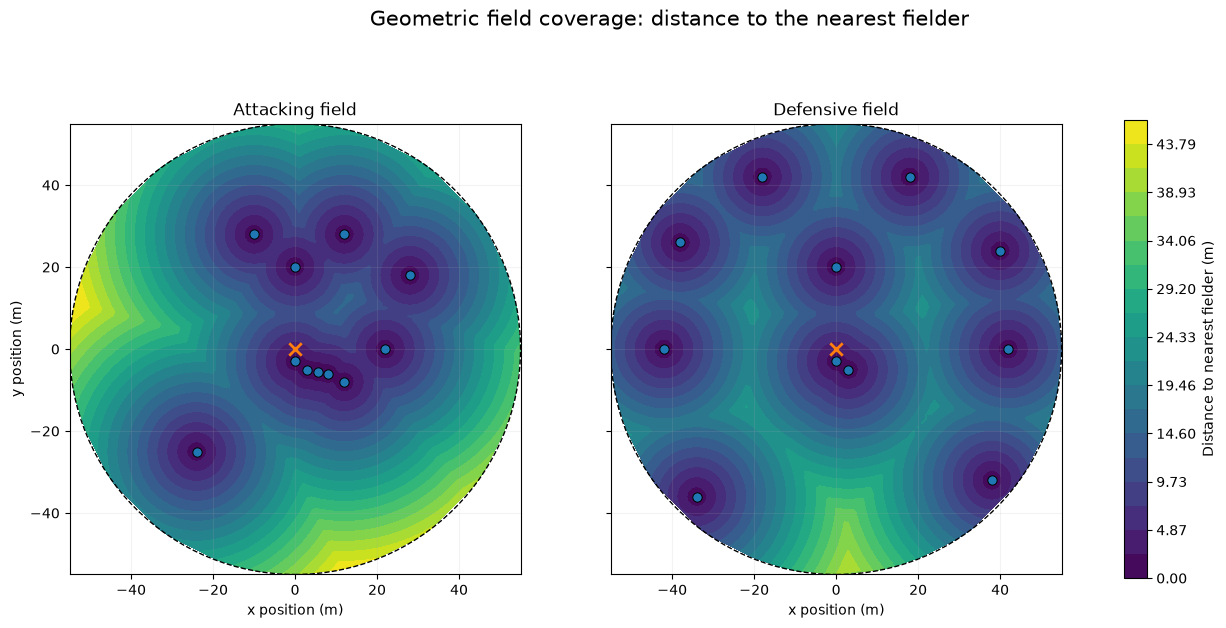

In [5]:
import matplotlib.pyplot as plt

# Use one common distance scale so the two maps are directly comparable.
distance_max = max(
    coverage_grid["attacking_nearest_distance_m"].max(),
    coverage_grid["defensive_nearest_distance_m"].max(),
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 7),
    sharex=True,
    sharey=True,
)

field_settings = [
    (
        axes[0],
        attacking_field,
        "attacking_nearest_distance_m",
        "Attacking field",
    ),
    (
        axes[1],
        defensive_field,
        "defensive_nearest_distance_m",
        "Defensive field",
    ),
]

for ax, field_df, distance_col, title in field_settings:

    # Plot the nearest-fielder distance across the analysis region.
    coverage = ax.tricontourf(
        coverage_grid["x_m"],
        coverage_grid["y_m"],
        coverage_grid[distance_col],
        levels=np.linspace(0, distance_max, 20),
        cmap="viridis",
        vmin=0,
        vmax=distance_max,
    )

    # Overlay the actual fielder locations.
    ax.scatter(
        field_df["x_m"],
        field_df["y_m"],
        s=45,
        edgecolor="black",
        linewidth=0.7,
        zorder=3,
    )

    # Mark the striker's wicket.
    ax.scatter(
        0,
        0,
        marker="x",
        s=80,
        linewidth=2,
        zorder=4,
    )

    # Show the edge of the fixed analysis region.
    analysis_circle = plt.Circle(
        (0, 0),
        analysis_radius_m,
        fill=False,
        linestyle="--",
        linewidth=1,
    )
    ax.add_patch(analysis_circle)

    ax.set_title(title)
    ax.set_xlabel("x position (m)")
    ax.set_aspect("equal")
    ax.set_xlim(-analysis_radius_m, analysis_radius_m)
    ax.set_ylim(-analysis_radius_m, analysis_radius_m)
    ax.grid(alpha=0.15)

axes[0].set_ylabel("y position (m)")

fig.colorbar(
    coverage,
    ax=axes,
    label="Distance to nearest fielder (m)",
    shrink=0.85,
)

fig.suptitle(
    "Geometric field coverage: distance to the nearest fielder",
    fontsize=15,
)

plt.show()

## What the coverage maps reveal

The two fields produce very different spatial patterns.

The attacking field concentrates several players into a small area behind the striker on the off side. Around the wicket-keeper, slips and gully, the nearest-fielder distance is therefore extremely small.

But those fielders are not available elsewhere.

Large parts of the attacking field consequently have much greater nearest-fielder distances, particularly across the leg side and in some deeper areas of the field.

The defensive setting makes the opposite trade-off.

Its fielders are distributed much more widely around the analysis region. There are fewer tightly packed areas, but there are also far fewer very large gaps between fielders.

This explains the earlier summary statistics:

    mean nearest-fielder distance
    Attacking: 18.53 m
    Defensive: 13.69 m

    90th percentile nearest-fielder distance
    Attacking: 33.18 m
    Defensive: 22.47 m

The defensive field therefore provides more even **geometric coverage of space**.

That is not the same thing as saying it is the better cricket field.

The attacking field deliberately sacrifices coverage elsewhere in order to place several fielders close together in an area where catches may be particularly valuable.

Our model can now show the spatial cost of making that choice.

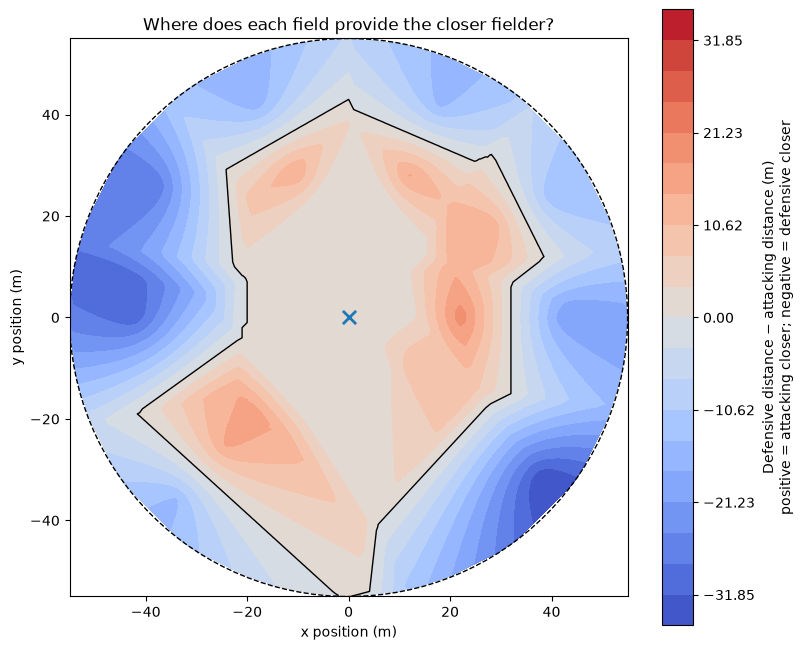

In [6]:
# Compare the two fields point by point.
#
# Positive values:
#   the attacking field has the nearer fielder.
#
# Negative values:
#   the defensive field has the nearer fielder.

coverage_grid["coverage_difference_m"] = (
    coverage_grid["defensive_nearest_distance_m"]
    - coverage_grid["attacking_nearest_distance_m"]
)

# Use a symmetric scale around zero so the two directions
# of the comparison are visually equivalent.
difference_limit = coverage_grid["coverage_difference_m"].abs().max()

fig, ax = plt.subplots(figsize=(9, 8))

difference_map = ax.tricontourf(
    coverage_grid["x_m"],
    coverage_grid["y_m"],
    coverage_grid["coverage_difference_m"],
    levels=np.linspace(-difference_limit, difference_limit, 21),
    cmap="coolwarm",
)

# Mark locations where the two fields have exactly the same
# nearest-fielder distance.
ax.tricontour(
    coverage_grid["x_m"],
    coverage_grid["y_m"],
    coverage_grid["coverage_difference_m"],
    levels=[0],
    colors="black",
    linewidths=1,
)

# Mark the striker's wicket.
ax.scatter(
    0,
    0,
    marker="x",
    s=90,
    linewidth=2,
    zorder=4,
)

analysis_circle = plt.Circle(
    (0, 0),
    analysis_radius_m,
    fill=False,
    linestyle="--",
    linewidth=1,
)
ax.add_patch(analysis_circle)

ax.set_title("Where does each field provide the closer fielder?")
ax.set_xlabel("x position (m)")
ax.set_ylabel("y position (m)")
ax.set_aspect("equal")
ax.set_xlim(-analysis_radius_m, analysis_radius_m)
ax.set_ylim(-analysis_radius_m, analysis_radius_m)

fig.colorbar(
    difference_map,
    ax=ax,
    label=(
        "Defensive distance − attacking distance (m)\n"
        "positive = attacking closer; negative = defensive closer"
    ),
)

plt.show()

## The defensive field covers more space, and by a larger margin

The point-by-point comparison reinforces what we saw in the coverage maps.

Across the 55-metre analysis region:

    Defensive field closer: 53.85%
    Attacking field closer: 34.99%
    Tie:                    11.16%

The defensive field therefore has the nearer fielder across more than half of the area we are measuring.

The difference is not only in the amount of space covered.

Where the defensive field is closer, its nearest fielder is closer by an average of:

    12.80 m

Where the attacking field is closer, its average advantage is:

    5.88 m

So the defensive field tends to gain a relatively large geometric advantage across the outer areas where its fielders have been spread around the ground.

The attacking field gains its advantage in a smaller region, concentrated around its close fielders.

The tied areas occur largely because the two settings share several identical positions, including the bowler, wicket-keeper and first slip.

This gives us a useful description of the tactical trade-off represented by these two illustrative fields:

    attacking field
    → concentrate players in selected areas
    → tighter local coverage
    → larger gaps elsewhere

    defensive field
    → distribute players more widely
    → less local concentration
    → more even coverage across the field

These results still describe geometry rather than cricketing value. A relatively small area may be extremely important if the ball is much more likely to travel there or if a chance there is particularly valuable.

In [7]:
# Find the most exposed grid point under each field setting:
# the location with the largest distance to its nearest fielder.

most_exposed_rows = []

for field_name, distance_col, fielder_col in [
    (
        "Attacking",
        "attacking_nearest_distance_m",
        "attacking_nearest_fielder",
    ),
    (
        "Defensive",
        "defensive_nearest_distance_m",
        "defensive_nearest_fielder",
    ),
]:
    max_index = coverage_grid[distance_col].idxmax()
    row = coverage_grid.loc[max_index]

    most_exposed_rows.append(
        {
            "field": field_name,
            "x_m": row["x_m"],
            "y_m": row["y_m"],
            "distance_from_striker_m": row["distance_from_striker_m"],
            "nearest_fielder": row[fielder_col],
            "nearest_fielder_distance_m": row[distance_col],
        }
    )

most_exposed = pd.DataFrame(most_exposed_rows)

most_exposed.round(2)

,field,x_m,y_m,distance_from_striker_m,nearest_fielder,nearest_fielder_distance_m
0,Attacking,-53,11,54.13,Fine leg,46.23
1,Defensive,3,-54,54.08,Fine leg,41.15


## Does the trade-off change with distance from the striker?

The most exposed points in both fields occur close to the edge of our 55-metre analysis region.

That makes the maximum nearest-fielder distance sensitive to the arbitrary size of the region we chose to analyse. Increasing or decreasing the radius could change both the location and value of the maximum.

A more useful question is therefore:

**How does coverage change as we move farther away from the striker?**

The field settings suggest a clear hypothesis.

The attacking field places several players close to the wicket, so we might expect it to provide relatively tight coverage in the inner part of the field.

The defensive field positions more players deeper, so we might expect its advantage to grow farther from the striker.

We can test this by dividing the analysis region into concentric distance bands and calculating the mean nearest-fielder distance within each band.

This lets us distinguish:

    close coverage
    from
    deep coverage

rather than compressing the entire field into one overall average.

In [8]:
# Divide the analysis region into concentric distance bands.

radial_bins = [0, 10, 20, 30, 40, 50, 55]
radial_labels = [
    "0–10 m",
    "10–20 m",
    "20–30 m",
    "30–40 m",
    "40–50 m",
    "50–55 m",
]

coverage_grid["radial_band"] = pd.cut(
    coverage_grid["distance_from_striker_m"],
    bins=radial_bins,
    labels=radial_labels,
    include_lowest=True,
)

radial_coverage = (
    coverage_grid
    .groupby("radial_band", observed=True)
    .agg(
        grid_points=("x_m", "size"),
        attacking_mean_distance_m=(
            "attacking_nearest_distance_m",
            "mean",
        ),
        defensive_mean_distance_m=(
            "defensive_nearest_distance_m",
            "mean",
        ),
    )
    .reset_index()
)

# Positive values mean the defensive field has the closer
# nearest fielder on average within that distance band.
radial_coverage["attacking_minus_defensive_m"] = (
    radial_coverage["attacking_mean_distance_m"]
    - radial_coverage["defensive_mean_distance_m"]
)

radial_coverage.round(2)

,radial_band,grid_points,attacking_mean_distance_m,defensive_mean_distance_m,attacking_minus_defensive_m
0,0–10 m,317,6.33,6.58,-0.25
1,10–20 m,940,10.40,12.31,-1.91
2,20–30 m,1564,12.12,17.30,-5.18
3,30–40 m,2204,15.15,15.05,0.10
4,40–50 m,2820,22.67,11.69,10.98
5,50–55 m,1632,29.13,14.03,15.10


## Attacking coverage is concentrated closer to the striker

Dividing the field by distance from the striker reveals a much clearer spatial trade-off.

Within 30 metres, the attacking field has the smaller mean nearest-fielder distance:

    0–10 m:    attacking closer by 0.25 m
    10–20 m:   attacking closer by 1.91 m
    20–30 m:   attacking closer by 5.18 m

Between 30 and 40 metres, the two fields are effectively level:

    30–40 m:   defensive closer by only 0.10 m

Beyond 40 metres, the relationship reverses dramatically:

    40–50 m:   defensive closer by 10.98 m
    50–55 m:   defensive closer by 15.10 m

This gives us a more precise description of what the two field settings are doing.

The attacking field concentrates its resources nearer the striker. Its close catchers and relatively shallow fielders reduce the gaps through the inner part of the field.

The defensive field gives up some of that close concentration and places more players deeper. As a result, its geometric advantage becomes increasingly strong towards the outside of the analysis region.

So the distinction can be expressed as a spatial redistribution:

    attacking
    → stronger inner coverage
    → weaker deep coverage

    defensive
    → weaker inner concentration
    → much stronger deep coverage

The 30–40 metre band appears to be an approximate transition zone for these particular illustrative fields.

That transition is a result of the coordinates chosen for these two examples, not a universal distance at which cricket fields become attacking or defensive.

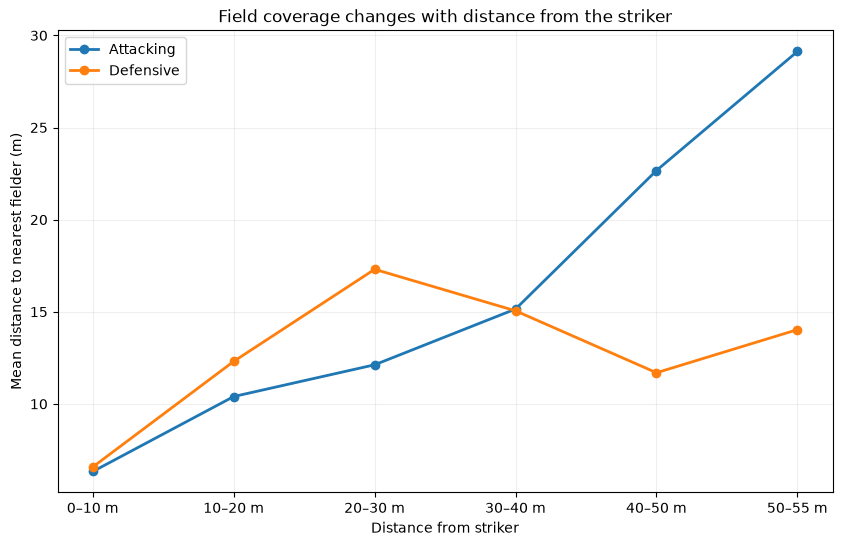

In [9]:
# Plot how mean nearest-fielder distance changes with distance from the striker.

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(radial_coverage))

ax.plot(
    x,
    radial_coverage["attacking_mean_distance_m"],
    marker="o",
    linewidth=2,
    label="Attacking",
)

ax.plot(
    x,
    radial_coverage["defensive_mean_distance_m"],
    marker="o",
    linewidth=2,
    label="Defensive",
)

ax.set_xticks(x)
ax.set_xticklabels(radial_coverage["radial_band"])

ax.set_xlabel("Distance from striker")
ax.set_ylabel("Mean distance to nearest fielder (m)")
ax.set_title("Field coverage changes with distance from the striker")

ax.legend()
ax.grid(alpha=0.2)

plt.show()

## The shape of the curves reveals two different field structures

The radial comparison makes the contrast between the two fields particularly clear.

For the attacking field, mean nearest-fielder distance generally increases as we move away from the striker.

That makes sense geometrically. Several of its fielders have been concentrated close to the wicket, so moving farther away increasingly takes us into the larger spaces left beyond them.

The defensive field behaves differently.

Its mean nearest-fielder distance rises from the striker out to the 20–30 metre band, but then begins to fall:

    0–10 m:    6.58 m
    10–20 m:  12.31 m
    20–30 m:  17.30 m
    30–40 m:  15.05 m
    40–50 m:  11.69 m

This happens because the defensive field contains a ring of deeper fielders. Once we move far enough from the striker, we begin approaching those players rather than moving away from everyone.

The two curves therefore describe different spatial structures:

    attacking field
    → dense inner concentration
    → progressively larger gaps farther out

    defensive field
    → relatively sparse middle region
    → tighter coverage again near the deep fielders

The crossover around 30–40 metres is especially useful because it shows that the difference between these fields is not simply "more coverage" versus "less coverage".

It is a redistribution of coverage across distance from the striker.

## A controlled experiment: move one fielder

So far we have compared two completely different field settings.

That tells us a lot about their overall structure, but it does not isolate the effect of any single tactical change.

We will now make a much smaller intervention.

Starting from the attacking field, we will move:

    Point
    (22, 0)

to:

    Deep point
    (42, 0)

Every other fielder will remain exactly where they are.

This gives us a controlled comparison:

    original attacking field
    versus
    attacking field with point moved deeper

Because only one coordinate changes, any change in the coverage surface must come from that movement.

We can then ask:

- which areas gain closer coverage;
- which areas lose closer coverage;
- how large those changes are;
- whether the overall mean coverage improves or deteriorates;
- and how coverage shifts between the inner and outer parts of the field.

This is closer to the kind of spatial decision a captain actually makes.

Moving a fielder does not simply "add coverage" somewhere else. It also removes that fielder's previous coverage from the area they leave behind.

In [10]:
# Create a copy of the attacking field so the original remains unchanged.

attacking_deep_point_field = attacking_field.copy()

# Move Point from (22, 0) to Deep point at (42, 0).
point_mask = (
    attacking_deep_point_field["position"] == "Point"
)

attacking_deep_point_field.loc[
    point_mask,
    ["position", "x_m", "y_m"],
] = ["Deep point", 42.0, 0.0]

# Show the changed position.
attacking_deep_point_field.loc[
    attacking_deep_point_field["position"] == "Deep point"
]

,position,x_m,y_m,field
6,Deep point,42.0,0.0,Attacking


In [11]:
# Recalculate nearest-fielder coverage after moving Point to Deep point.

add_nearest_fielder(
    coverage_grid,
    attacking_deep_point_field,
    "attacking_deep_point",
)

# Compare the modified field with the original attacking field.
#
# Positive values:
#   moving Point deeper gives a closer nearest fielder.
#
# Negative values:
#   the original Point position gave a closer nearest fielder.

coverage_grid["deep_point_change_m"] = (
    coverage_grid["attacking_nearest_distance_m"]
    - coverage_grid["attacking_deep_point_nearest_distance_m"]
)

point_move_summary = pd.DataFrame(
    {
        "field_setting": [
            "Original attacking",
            "Point → Deep point",
        ],
        "mean_nearest_distance_m": [
            coverage_grid["attacking_nearest_distance_m"].mean(),
            coverage_grid["attacking_deep_point_nearest_distance_m"].mean(),
        ],
        "median_nearest_distance_m": [
            coverage_grid["attacking_nearest_distance_m"].median(),
            coverage_grid["attacking_deep_point_nearest_distance_m"].median(),
        ],
        "p90_nearest_distance_m": [
            coverage_grid["attacking_nearest_distance_m"].quantile(0.90),
            coverage_grid["attacking_deep_point_nearest_distance_m"].quantile(0.90),
        ],
    }
)

point_move_summary.round(2)

,field_setting,mean_nearest_distance_m,median_nearest_distance_m,p90_nearest_distance_m
0,Original attacking,18.53,17.49,33.18
1,Point → Deep point,17.73,16.12,32.28


## Moving one fielder improves the average but redistributes the gaps

Moving Point from `(22, 0)` to Deep point at `(42, 0)` changes only one player, but it is enough to alter the overall coverage statistics.

The mean nearest-fielder distance falls from:

    18.53 m
    to
    17.73 m

The median falls from:

    17.49 m
    to
    16.12 m

And the 90th percentile falls from:

    33.18 m
    to
    32.28 m

Under our equal-area geometric measure, the modified field therefore covers the 55-metre analysis region more closely overall.

But an improvement in the average does not mean every part of the field improves.

Moving Point deeper creates two effects at the same time:

    original Point area
    → fielder removed
    → some nearby locations become less closely covered

    deeper off-side area
    → fielder added
    → some locations become more closely covered

The important question is therefore not simply whether the overall average rises or falls.

It is:

**Where did the field gain coverage, and where did it lose coverage?**

A point-by-point difference map will let us see that redistribution directly.

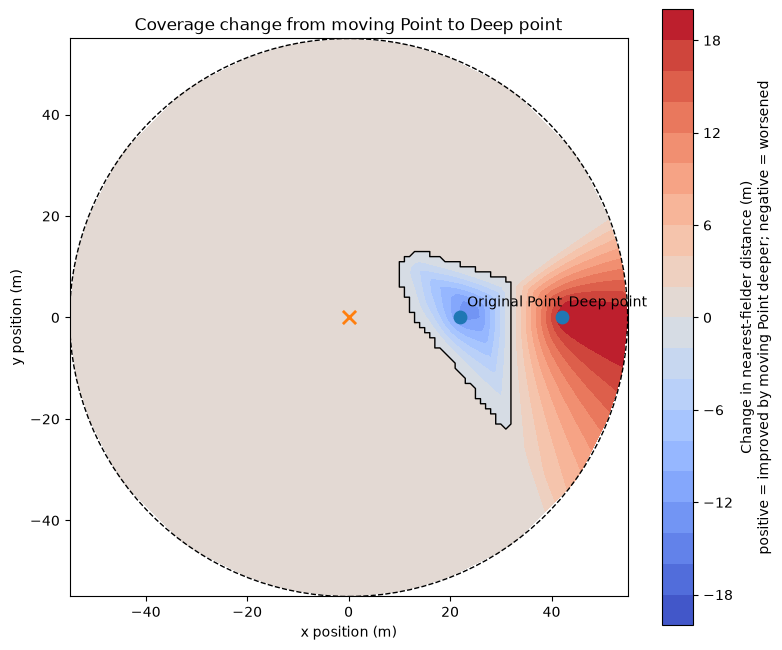

In [12]:
# Map where moving Point to Deep point improves or worsens coverage.

change_limit = coverage_grid["deep_point_change_m"].abs().max()

fig, ax = plt.subplots(figsize=(9, 8))

change_map = ax.tricontourf(
    coverage_grid["x_m"],
    coverage_grid["y_m"],
    coverage_grid["deep_point_change_m"],
    levels=np.linspace(-change_limit, change_limit, 21),
    cmap="coolwarm",
)

# Zero contour:
# no change in nearest-fielder distance.
ax.tricontour(
    coverage_grid["x_m"],
    coverage_grid["y_m"],
    coverage_grid["deep_point_change_m"],
    levels=[0],
    colors="black",
    linewidths=1,
)

# Show the original Point and new Deep point locations.
ax.scatter(
    [22, 42],
    [0, 0],
    s=80,
    zorder=4,
)

ax.annotate(
    "Original Point",
    (22, 0),
    xytext=(5, 8),
    textcoords="offset points",
)

ax.annotate(
    "Deep point",
    (42, 0),
    xytext=(5, 8),
    textcoords="offset points",
)

# Mark the striker's wicket.
ax.scatter(
    0,
    0,
    marker="x",
    s=90,
    linewidth=2,
    zorder=4,
)

analysis_circle = plt.Circle(
    (0, 0),
    analysis_radius_m,
    fill=False,
    linestyle="--",
    linewidth=1,
)
ax.add_patch(analysis_circle)

ax.set_title("Coverage change from moving Point to Deep point")
ax.set_xlabel("x position (m)")
ax.set_ylabel("y position (m)")
ax.set_aspect("equal")
ax.set_xlim(-analysis_radius_m, analysis_radius_m)
ax.set_ylim(-analysis_radius_m, analysis_radius_m)

fig.colorbar(
    change_map,
    ax=ax,
    label=(
        "Change in nearest-fielder distance (m)\n"
        "positive = improved by moving Point deeper; "
        "negative = worsened"
    ),
)

plt.show()

## One move changes only part of the field

The difference map shows something that the overall averages could not.

Moving Point from 22 metres to 42 metres on the off side does not alter coverage everywhere.

Most of the analysis region is unchanged because Point was not the nearest fielder there before or after the move.

The affected area is concentrated around the path between the two positions.

Close to the original Point position, coverage becomes worse because that nearby fielder has been removed.

Farther out on the off side, coverage improves because Deep point is now substantially closer.

This illustrates an important property of a field change:

    move one fielder
    → lose local coverage around the old position
    → gain coverage around the new position
    → leave much of the rest of the field unchanged

The improvement in the overall mean therefore comes from the geometry of those gains and losses rather than from a universal improvement across the field.

We can quantify that trade-off by measuring:

- the proportion of the analysis region that improves;
- the proportion that worsens;
- the proportion that is unchanged;
- and the average size of the gain or loss within the affected areas.

In [13]:
# Quantify how much of the analysis region improves, worsens,
# or remains effectively unchanged after moving Point deeper.

change_tolerance_m = 0.01

coverage_grid["point_move_effect"] = np.select(
    [
        coverage_grid["deep_point_change_m"] > change_tolerance_m,
        coverage_grid["deep_point_change_m"] < -change_tolerance_m,
    ],
    [
        "Improved",
        "Worsened",
    ],
    default="Unchanged",
)

point_move_area = (
    coverage_grid["point_move_effect"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("area_share_pct")
    .to_frame()
)

# Mean size of the change within each affected area.
point_move_area.loc["Improved", "mean_change_m"] = (
    coverage_grid.loc[
        coverage_grid["point_move_effect"] == "Improved",
        "deep_point_change_m",
    ].mean()
)

point_move_area.loc["Worsened", "mean_change_m"] = (
    -coverage_grid.loc[
        coverage_grid["point_move_effect"] == "Worsened",
        "deep_point_change_m",
    ].mean()
)

point_move_area.loc["Unchanged", "mean_change_m"] = 0.0

point_move_area.round(2)

,area_share_pct,mean_change_m
point_move_effect,,
Unchanged,85.68,0.00
Improved,10.20,9.78
Worsened,4.12,4.85


## A local change can alter the overall field

Moving Point to Deep point leaves most of the field untouched:

    Unchanged: 85.68%

Only 14.32% of the analysis region changes its nearest-fielder distance.

Within that affected area, however, the gains and losses are asymmetric:

    Improved: 10.20% of the region
    Mean improvement: 9.78 m

    Worsened: 4.12% of the region
    Mean deterioration: 4.85 m

So the move improves coverage across a larger area than it worsens, and the average improvement within that area is also roughly twice as large as the average deterioration.

That explains why the overall mean nearest-fielder distance fell from 18.53 metres to 17.73 metres.

This is an important distinction.

The field has not become uniformly better covered. Instead, one local loss has been exchanged for a larger and stronger gain elsewhere.

Under this geometric model:

    Point → Deep point

produces:

    small shallow coverage loss
    +
    larger deep coverage gain
    =
    lower overall nearest-fielder distance

Whether that is a good cricket decision would depend on the value and likelihood of balls entering those different areas, which our model does not yet include.

In [14]:
# Measure where the Point -> Deep point gains and losses occur
# as we move farther from the striker.

radial_point_move = (
    coverage_grid
    .groupby("radial_band", observed=True)
    .agg(
        grid_points=("x_m", "size"),
        mean_change_m=("deep_point_change_m", "mean"),
        improved_pct=(
            "point_move_effect",
            lambda x: (x == "Improved").mean() * 100,
        ),
        worsened_pct=(
            "point_move_effect",
            lambda x: (x == "Worsened").mean() * 100,
        ),
        unchanged_pct=(
            "point_move_effect",
            lambda x: (x == "Unchanged").mean() * 100,
        ),
    )
    .reset_index()
)

radial_point_move.round(2)

,radial_band,grid_points,mean_change_m,improved_pct,worsened_pct,unchanged_pct
0,0–10 m,317,0.00,0.00,0.00,100.00
1,10–20 m,940,-0.42,0.00,11.17,88.83
2,20–30 m,1564,-0.85,0.00,13.30,86.70
3,30–40 m,2204,0.40,8.30,3.49,88.20
4,40–50 m,2820,1.74,16.81,0.00,83.19
5,50–55 m,1632,2.15,19.00,0.00,81.00


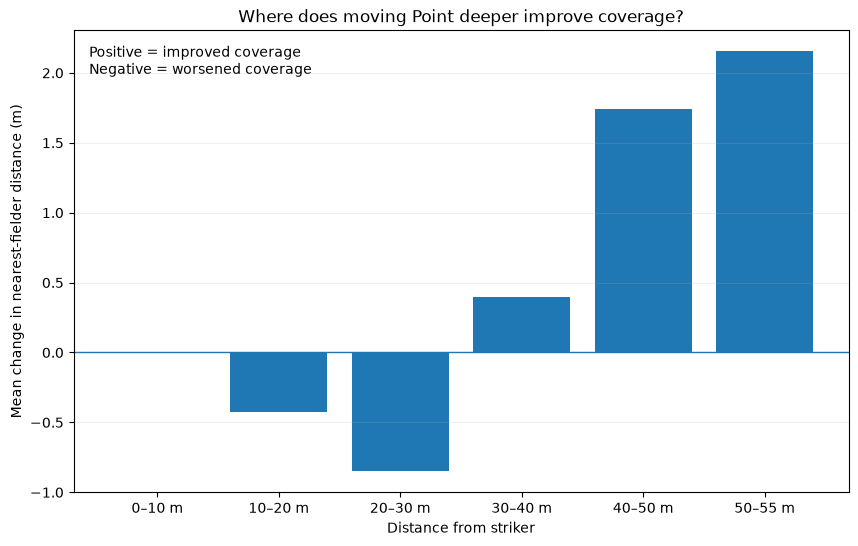

In [15]:
# Plot the average effect of moving Point to Deep point
# within each radial distance band.

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(radial_point_move))

ax.bar(
    x,
    radial_point_move["mean_change_m"],
)

ax.axhline(
    0,
    linewidth=1,
)

ax.set_xticks(x)
ax.set_xticklabels(radial_point_move["radial_band"])

ax.set_xlabel("Distance from striker")
ax.set_ylabel("Mean change in nearest-fielder distance (m)")
ax.set_title("Where does moving Point deeper improve coverage?")

ax.text(
    0.02,
    0.97,
    "Positive = improved coverage\nNegative = worsened coverage",
    transform=ax.transAxes,
    va="top",
)

ax.grid(axis="y", alpha=0.2)

plt.show()

## Moving Point deeper shifts coverage outward

The radial comparison shows exactly where the Point-to-Deep-point trade-off occurs.

Within 10 metres of the striker, nothing changes:

    0–10 m:
    100% unchanged

That makes sense because Point was not the nearest fielder to locations that close to the wicket.

Between 10 and 30 metres, the move makes coverage worse:

    10–20 m:
    mean change = -0.42 m
    11.17% of the band worsened

    20–30 m:
    mean change = -0.85 m
    13.30% of the band worsened

This is the spatial cost of removing Point from the shallower off-side area.

The balance begins to reverse between 30 and 40 metres:

    30–40 m:
    mean change = +0.40 m
    8.30% improved
    3.49% worsened

Beyond 40 metres, the effect is entirely in the other direction:

    40–50 m:
    mean change = +1.74 m
    16.81% improved
    0% worsened

    50–55 m:
    mean change = +2.15 m
    19.00% improved
    0% worsened

So moving Point to Deep point does not simply improve or worsen the field.

It moves coverage outward:

    shallower off-side coverage
    → reduced

    deeper off-side coverage
    → increased

This is the same broader trade-off we observed when comparing the complete attacking and defensive fields, but now it has been isolated to a single fielding change.

A tactical instruction such as "push Point back" can therefore be represented as a measurable redistribution of space rather than only as a change in a named position.

## A second experiment: move a fielder around the striker

The Point-to-Deep-point experiment changed a fielder's **depth**.

We can also use the same framework to study a different kind of tactical adjustment: changing a fielder's **angle** around the striker while keeping roughly the same distance from the wicket.

Starting from the defensive field, we will move:

    Deep square leg
    (-42, 0)

to a representative **Deep backward square leg** position approximately 30 degrees behind square:

    (-36.37, -21)

Both locations are 42 metres from the striker.

So this experiment deliberately holds radial depth constant:

    distance from striker = 42 m

while changing direction.

Every other fielder will remain unchanged.

This lets us isolate a different spatial question:

**What happens to field coverage when a fielder moves around the field rather than simply moving deeper or shallower?**

We should expect the change to redistribute coverage angularly:

    around square leg
    → coverage lost

    behind square on the leg side
    → coverage gained

As before, the exact new coordinate is a modelling choice rather than a fixed definition of where a real deep backward square leg must stand.

In [16]:
# Create a copy of the defensive field so the original remains unchanged.

defensive_backward_square_field = defensive_field.copy()

# Move Deep square leg around the striker while keeping
# approximately the same 42 m radial distance.
square_leg_mask = (
    defensive_backward_square_field["position"] == "Deep square leg"
)

defensive_backward_square_field.loc[
    square_leg_mask,
    ["position", "x_m", "y_m"],
] = ["Deep backward square leg", -36.37, -21.0]

# Compare the original and modified positions.
angular_move_check = pd.DataFrame(
    [
        {
            "field_setting": "Original",
            "position": "Deep square leg",
            "x_m": -42.0,
            "y_m": 0.0,
        },
        {
            "field_setting": "Moved",
            "position": "Deep backward square leg",
            "x_m": -36.37,
            "y_m": -21.0,
        },
    ]
)

angular_move_check["distance_from_striker_m"] = np.hypot(
    angular_move_check["x_m"],
    angular_move_check["y_m"],
)

angular_move_check.round(2)

,field_setting,position,x_m,y_m,distance_from_striker_m
0,Original,Deep square leg,-42.00,0.0,42.0
1,Moved,Deep backward square leg,-36.37,-21.0,42.0


In [17]:
# Recalculate coverage after moving Deep square leg
# to Deep backward square leg.

add_nearest_fielder(
    coverage_grid,
    defensive_backward_square_field,
    "defensive_backward_square",
)

# Compare the modified field with the original defensive field.
#
# Positive values:
#   the moved position gives a closer nearest fielder.
#
# Negative values:
#   the original Deep square leg position was closer.

coverage_grid["backward_square_change_m"] = (
    coverage_grid["defensive_nearest_distance_m"]
    - coverage_grid["defensive_backward_square_nearest_distance_m"]
)

angular_move_summary = pd.DataFrame(
    {
        "field_setting": [
            "Original defensive",
            "Deep square leg → Deep backward square leg",
        ],
        "mean_nearest_distance_m": [
            coverage_grid["defensive_nearest_distance_m"].mean(),
            coverage_grid[
                "defensive_backward_square_nearest_distance_m"
            ].mean(),
        ],
        "median_nearest_distance_m": [
            coverage_grid["defensive_nearest_distance_m"].median(),
            coverage_grid[
                "defensive_backward_square_nearest_distance_m"
            ].median(),
        ],
        "p90_nearest_distance_m": [
            coverage_grid["defensive_nearest_distance_m"].quantile(0.90),
            coverage_grid[
                "defensive_backward_square_nearest_distance_m"
            ].quantile(0.90),
        ],
    }
)

angular_move_summary.round(2)

,field_setting,mean_nearest_distance_m,median_nearest_distance_m,p90_nearest_distance_m
0,Original defensive,13.69,12.81,22.47
1,Deep square leg → Deep backward square leg,13.99,13.04,23.35


## Moving around the field can redistribute coverage without improving it overall

Moving Deep square leg to Deep backward square leg keeps the fielder at the same 42-metre depth from the striker.

Only the direction changes.

Unlike the earlier Point-to-Deep-point move, this adjustment slightly worsens the overall coverage statistics:

    Mean nearest-fielder distance:
    13.69 m → 13.99 m

    Median nearest-fielder distance:
    12.81 m → 13.04 m

    90th percentile nearest-fielder distance:
    22.47 m → 23.35 m

Under our equal-area geometric measure, the original defensive field therefore covers the whole analysis region slightly more efficiently.

But that does not mean the angular move is simply a bad fielding decision.

The purpose of moving a fielder backward of square would normally be to protect a different part of the field.

The important question is therefore again spatial:

    square-leg area
    → coverage likely reduced

    backward-square-leg area
    → coverage likely increased

The overall average suggests that the area gained does not completely compensate for the area lost.

We now need to map those gains and losses directly.

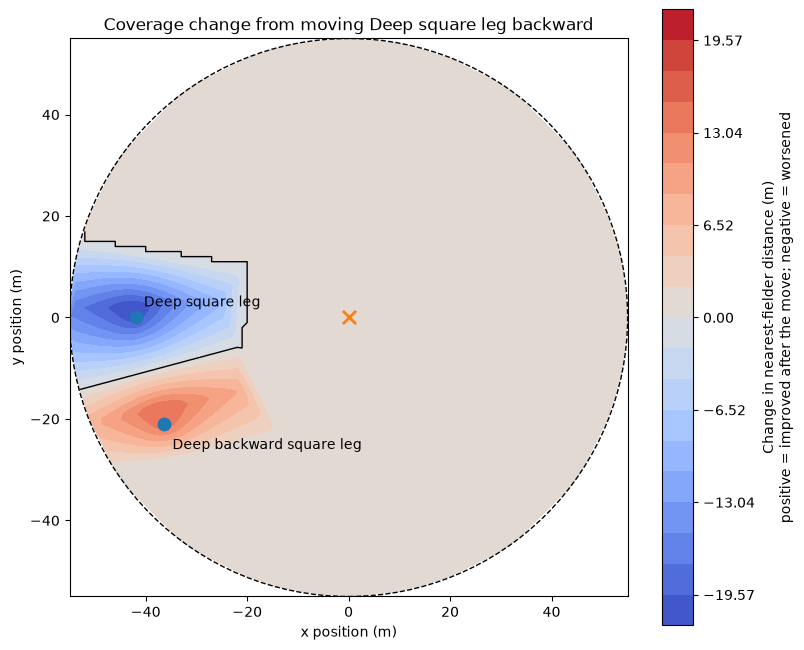

In [18]:
# Map where moving Deep square leg to Deep backward square leg
# improves or worsens coverage.

angular_change_limit = coverage_grid[
    "backward_square_change_m"
].abs().max()

fig, ax = plt.subplots(figsize=(9, 8))

angular_change_map = ax.tricontourf(
    coverage_grid["x_m"],
    coverage_grid["y_m"],
    coverage_grid["backward_square_change_m"],
    levels=np.linspace(
        -angular_change_limit,
        angular_change_limit,
        21,
    ),
    cmap="coolwarm",
)

# Zero contour:
# no change in nearest-fielder distance.
ax.tricontour(
    coverage_grid["x_m"],
    coverage_grid["y_m"],
    coverage_grid["backward_square_change_m"],
    levels=[0],
    colors="black",
    linewidths=1,
)

# Show the old and new fielder locations.
ax.scatter(
    [-42.0, -36.37],
    [0.0, -21.0],
    s=80,
    zorder=4,
)

ax.annotate(
    "Deep square leg",
    (-42.0, 0.0),
    xytext=(6, 8),
    textcoords="offset points",
)

ax.annotate(
    "Deep backward square leg",
    (-36.37, -21.0),
    xytext=(6, -18),
    textcoords="offset points",
)

# Mark the striker's wicket.
ax.scatter(
    0,
    0,
    marker="x",
    s=90,
    linewidth=2,
    zorder=4,
)

analysis_circle = plt.Circle(
    (0, 0),
    analysis_radius_m,
    fill=False,
    linestyle="--",
    linewidth=1,
)
ax.add_patch(analysis_circle)

ax.set_title(
    "Coverage change from moving Deep square leg backward"
)
ax.set_xlabel("x position (m)")
ax.set_ylabel("y position (m)")
ax.set_aspect("equal")
ax.set_xlim(-analysis_radius_m, analysis_radius_m)
ax.set_ylim(-analysis_radius_m, analysis_radius_m)

fig.colorbar(
    angular_change_map,
    ax=ax,
    label=(
        "Change in nearest-fielder distance (m)\n"
        "positive = improved after the move; "
        "negative = worsened"
    ),
)

plt.show()

In [19]:
# Quantify the angular redistribution caused by moving
# Deep square leg to Deep backward square leg.

angular_change_tolerance_m = 0.01

coverage_grid["angular_move_effect"] = np.select(
    [
        coverage_grid["backward_square_change_m"] > angular_change_tolerance_m,
        coverage_grid["backward_square_change_m"] < -angular_change_tolerance_m,
    ],
    [
        "Improved",
        "Worsened",
    ],
    default="Unchanged",
)

angular_move_area = (
    coverage_grid["angular_move_effect"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("area_share_pct")
    .to_frame()
)

angular_move_area.loc["Improved", "mean_change_m"] = (
    coverage_grid.loc[
        coverage_grid["angular_move_effect"] == "Improved",
        "backward_square_change_m",
    ].mean()
)

angular_move_area.loc["Worsened", "mean_change_m"] = (
    -coverage_grid.loc[
        coverage_grid["angular_move_effect"] == "Worsened",
        "backward_square_change_m",
    ].mean()
)

angular_move_area.loc["Unchanged", "mean_change_m"] = 0.0

angular_move_area.round(2)

,area_share_pct,mean_change_m
angular_move_effect,,
Unchanged,85.25,0.00
Worsened,7.99,8.95
Improved,6.76,6.11


## An angular move redistributes coverage sideways

Moving Deep square leg backward while keeping the fielder 42 metres from the striker changes only a relatively small part of the field:

    Unchanged: 85.25%

The affected area is divided between gains and losses:

    Improved: 6.76% of the region
    Mean improvement: 6.11 m

    Worsened: 7.99% of the region
    Mean deterioration: 8.95 m

The map shows where those changes occur.

Coverage is lost around the original Deep square leg position and gained behind square around the new Deep backward square leg position.

Unlike the earlier Point-to-Deep-point experiment, however, the losses are both slightly larger in area and substantially larger in average magnitude than the gains.

That explains why the overall mean nearest-fielder distance increased slightly:

    13.69 m → 13.99 m

The two controlled experiments therefore demonstrate two different kinds of spatial adjustment:

    Point → Deep point
    → changes depth
    → shifts coverage outward

    Deep square leg → Deep backward square leg
    → changes angle
    → shifts coverage around the striker

In both cases, moving one fielder creates a trade-off rather than simply adding or removing coverage.

The nearest-fielder model gives us a way to locate and measure that trade-off.

We do not need to repeat the exercise for every named position. These two examples are sufficient to demonstrate how the same method can analyse both radial and angular field changes.

## What this study has established

Study 19 gave us a way to represent a cricket field as data:

    named fielding positions
    → coordinates

This study extended that representation into a simple model of spatial coverage:

    possible ball location
    + fielder coordinates
    → nearest fielder
    → nearest-fielder distance

That simple measure was enough to reveal several useful properties of the two illustrative fields.

Across the full 55-metre analysis region, the defensive field produced tighter geometric coverage overall:

    Mean nearest-fielder distance
    Attacking: 18.53 m
    Defensive: 13.69 m

But the radial analysis showed why that overall average is incomplete.

The attacking field provided tighter coverage through the inner 30 metres, while the defensive field became much stronger farther from the striker.

The distinction was therefore not simply:

    good coverage
    versus
    bad coverage

It was a redistribution of coverage with depth:

    attacking
    → greater inner concentration
    → larger deep gaps

    defensive
    → less inner concentration
    → much stronger deep coverage

The controlled experiments then showed that the same framework can measure individual field changes.

Moving Point to Deep point shifted coverage outward:

    shallow coverage
    → reduced

    deep coverage
    → increased

Moving Deep square leg backward shifted coverage around the striker:

    square-leg coverage
    → reduced

    behind-square coverage
    → increased

So a field change can be understood as a redistribution of space.

That is the main analytical result of this study:

**A cricket field is not only a set of named positions. It is a spatial allocation of limited fielding resources, where strengthening coverage in one area usually means weakening it somewhere else.**

## Conclusion

This study began with a simple question:

**How does changing a cricket field change which areas are well covered and which areas are left exposed?**

Using the coordinates developed in Study 19, we treated locations around the striker as possible ball destinations and measured the distance from each location to its nearest fielder.

That turned a field setting into a measurable coverage surface.

The comparison between our illustrative attacking and defensive fields showed that the defensive field covered the full analysis region more evenly, but the radial analysis revealed the more important result: the two fields allocated their coverage differently.

The attacking field concentrated players nearer the striker.

The defensive field concentrated more of its resources deeper around the field.

We then changed individual positions and showed that moving a fielder creates measurable gains and losses in different areas.

A fielding change can therefore be represented as:

    move a fielder
    → remove coverage from one area
    → add coverage to another
    → change the spatial structure of the field

That gives us a useful way to describe what a captain is doing geometrically.

But geometry is only the first half of the problem.

The next analytical step would be to introduce information about **where the ball actually goes**.

If ball destinations are not equally likely, then the important question becomes:

    spatial coverage
    × probability of the ball entering that space
    × value of the resulting outcome

At that point we could begin moving from:

**Where are the gaps?**

towards:

**Which gaps matter?**

For now, the key result is simpler:

**Field placement can be treated as a measurable allocation of limited coverage across space.**